In [21]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR100
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [23]:
train_transform = transforms.Compose([transforms.Resize((32,32)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
                               transforms.RandomCrop(32,padding=4,padding_mode='reflect'),transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((32,32)), transforms.ToTensor()])

In [24]:
train_data = CIFAR100(root='data', train=True, download=True, transform=train_transform)
test_data = CIFAR100(root='data', train=False, download=True, transform=test_transform)

In [25]:
train_data.classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [26]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

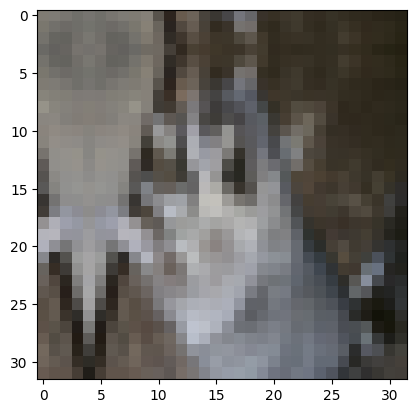

In [27]:
img, label = train_data[random.randint(0,len(train_data)-1)]
plt.imshow(img.permute(1,2,0))

In [28]:
class CifarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3,32,kernel_size=3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32,32,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(32),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(nn.Conv2d(32,64,kernel_size=3,padding=1), nn.BatchNorm2d(64),nn.ReLU(), nn.Conv2d(64,64,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(64),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(nn.Flatten(), nn.Dropout(p=0.5), nn.Linear(64*8*8, 512), nn.BatchNorm1d(512),
                                    nn.ReLU(), nn.Linear(512,100))
    def forward(self, x):
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        return self.layer3(x2)
model = CifarModel().to(device)

In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [30]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=20,gamma=0.2)

In [31]:
def acc_fn(pred,y):
    pred = pred.argmax(dim=1)
    acc = torch.eq(pred,y).sum().item()/len(pred)
    return acc*100

In [32]:
def train_step(model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device):
    model.train()
    acc = 0
    floss = 0
    for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = loss_fn(logits,y)
        loss.backward()
        optimizer.step()
        acc += acc_fn(logits, y)
        floss +=loss.item()
    return floss / len(dataloader), acc / len(dataloader)

def test_step(model,dataloader=test_dataloader,loss_fn=loss_fn, device=device):
    model.eval()
    acc = 0
    floss = 0
    with torch.inference_mode():
        for X,y in dataloader:
            X,y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits,y)
            acc += acc_fn(logits, y)
            floss += loss.item()
        return floss / len(dataloader), acc / len(dataloader)



In [ ]:
for epoch in range(51):
    train_loss, train_acc = train_step(model,optimizer=optimizer)
    test_loss, test_acc = test_step(model)
    scheduler.step()
    print(f'Epoch {epoch}\nTrain loss: {train_loss} Test loss: {test_loss}\nTrain acc:{train_acc} Test acc: {test_acc}')

Epoch 0
Train loss: 3.522421793226851 Test loss: 3.1054565213358822
Train acc:16.65467050543826 Test acc: 25.139776357827476
Epoch 1
Train loss: 2.980277978222262 Test loss: 2.7808942170188833
Train acc:26.02967050543826 Test acc: 30.50119808306709
Epoch 2
Train loss: 2.7282561574772393 Test loss: 2.5911598715919277
Train acc:30.742162507997442 Test acc: 34.105431309904155
Epoch 3
Train loss: 2.5618964728070464 Test loss: 2.478774743339124
Train acc:34.20505438259757 Test acc: 36.83107028753994
Epoch 4
Train loss: 2.4347540838780954 Test loss: 2.2892506061651456
Train acc:36.80022392834293 Test acc: 41.15415335463259
Epoch 5
Train loss: 2.337950643178216 Test loss: 2.2084002902332585
Train acc:39.02951055662188 Test acc: 42.67172523961661
Epoch 6
Train loss: 2.260491562438789 Test loss: 2.17085631472615
Train acc:40.52103326935381 Test acc: 43.170926517571885
Epoch 7
Train loss: 2.190953821611191 Test loss: 2.154438193613729
Train acc:42.07053742802303 Test acc: 43.76996805111821
Epoch

In [67]:
print(len(train_dataloader), len(test_dataloader))

1563 313


In [33]:
model2 = CifarModel()
state_dict = torch.load('model_weights.pth',map_location=device)
model2.load_state_dict(state_dict=state_dict)

<All keys matched successfully>

In [41]:
classes = train_data.classes

Prediction: caterpillar
Label: snake


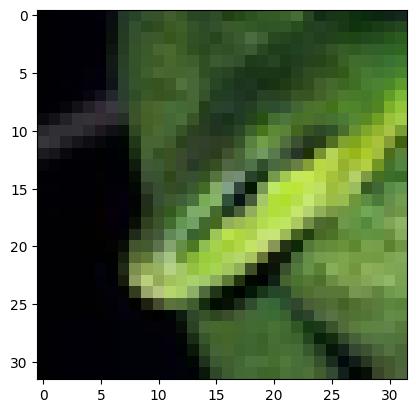

In [71]:
model2.eval()
with torch.inference_mode():
    img, label = test_data[random.randint(0,len(test_data)-1)]
    logits = model2(img.unsqueeze(dim=0))
    prediction = torch.argmax(logits,dim=1)
    plt.imshow(img.permute(1,2,0))
    print(f'Prediction: {classes[prediction.item()]}\nLabel: {classes[label]}')